In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

import xarray as xr
import pandas as pd
import geopandas as gpd
from glob import glob

import time

from cartopy.crs import Geodetic, PlateCarree
from cartopy.feature import LAND, COASTLINE

import warnings
warnings.simplefilter('ignore')

# Set Parameters

In [ ]:
# Parameters
year = 2024
site = 'DB01'
north_sea_locations = ''

In [3]:
# Set the basic mapping parameters
suptitle_size = 20
title_size = 16
map_size = (16, 8)
extent = (2.5, 27.5, 52, 62)
lon_mid = np.mean(extent[:2])
lat_mid = np.mean(extent[2:])
map_projection = PlateCarree()
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.gridlines(draw_labels=['left', 'bottom'], y_inline=False,)
    return ax

In [4]:
# Paths
project_folder_path = Path('/gxfs_work/geomar/smomw597/2025_copepods/')
trajectory_path = project_folder_path / f'output/Trajectories/{year}/'
sample_points_path = project_folder_path / f'output/sample_points/sample_points{north_sea_locations}.geojson'
voronoi_polygons_path = project_folder_path / f'output/sample_points/voronoi_polygons{north_sea_locations}.geojson'
output_path = project_folder_path / f'output/connectivity_matrices{north_sea_locations}/'

In [5]:
# Load the samplepoints and the voronoi polygons
sample_points = gpd.read_file(sample_points_path).set_index('location_id_old')
gdf_voronoi_polygons = gpd.read_file(voronoi_polygons_path)[['geometry', 'location_id']]
sample_ids = sample_points.index.to_list()
# Get site index, if the site name was given and the other way around
if type(site) == str:
    site_name = site
elif type(site) == int:
    site_name = sample_ids[site]
# set starting site to 'active'
sample_points.loc[site_name]['sample_kind'] = 'active'

In [6]:
# Read and prepare the trajectory file
trajectory_file = sorted(trajectory_path.glob(f'*{site_name}*'))[0]
ds_trajectories = xr.open_zarr(trajectory_file, chunks={'trajectory': 3000, 'obs': 3000})
# Make a mask that masks all days with an age under 10 days
trajectories_age_mask = ds_trajectories.age_sec.compute() > 10*24*60*60
# Only get the positions and mask
ds_trajectories = ds_trajectories.get(['lat','lon']).where(trajectories_age_mask, drop=True)

In [7]:
# Take the positions and build a pandas dataframe out of it, making it as small as possible
df_trajectories = ds_trajectories.to_dataframe().dropna()
# removing the xr Datset, as it is not longer needed but big in the memory
del ds_trajectories

In [8]:
# Build a Gepandas Gedataframe from the dataframe and delete the df afterwards to safe on memory
gdf_trajectories = gpd.GeoDataFrame(geometry=gpd.points_from_xy(df_trajectories['lon'], df_trajectories['lat'], crs=Geodetic()))
del df_trajectories

In [9]:
# Check for each particle which polygon contains it
gdf_trajectories = gdf_trajectories.sjoin(gdf_voronoi_polygons, how='left').drop(columns=['index_right'])

In [10]:
gdf_trajectories

,geometry,location_id
0,POINT (7.08465 55.59622),DB01
1,POINT (7.08662 55.59305),DB01
2,POINT (7.08963 55.58672),DB01
3,POINT (7.08963 55.58671),DB01
4,POINT (7.09053 55.58367),DB01
...,...,...
219915995,POINT (7.6153 56.42352),JB01
219915996,POINT (7.61463 56.42269),JB01
219915997,POINT (7.61283 56.42127),JB01
219915998,POINT (7.61205 56.4209),JB01


<Axes: xlabel='location_id'>

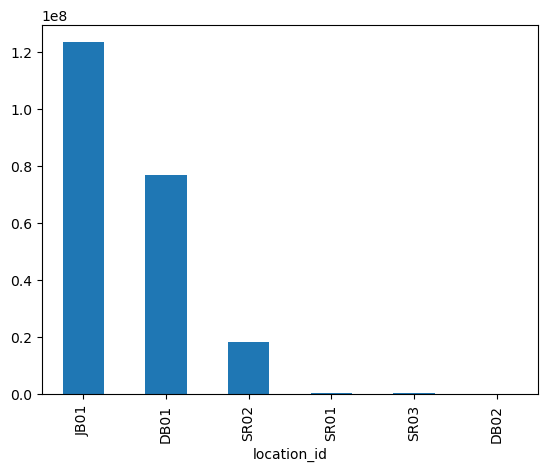

In [11]:
# Count the particles per polygon
polygon_count = gdf_trajectories.location_id.value_counts()
polygon_count.plot(kind='bar')

In [14]:
output_path.rglob('*nb')

<generator object Path.rglob at 0x15498ce4c040>

In [ ]:
# Write the counts per polygon into a connectivity matrix
output_file_path = output_path / f'connectivity_matrix{north_sea_locations}_{year}.csv'
files_list = list(output_path.glob(f'connectivity*'))

# If the connectivity matrix for the given year already exists, thake that
if output_file_path in files_list:
        connectivity_matrix = pd.read_csv(output_file_path, index_col=0)
        print('Updated file', output_file_path)
else:
        connectivity_matrix = pd.DataFrame(index=sample_ids, columns=sample_ids).fillna(0)
        print('Created a new file', output_file_path)
for polygon_id, count in polygon_count.items():
        connectivity_matrix.loc[[site_name], [polygon_id]] = count
connectivity_matrix.to_csv(output_file_path)
connectivity_matrix

Created a new file /gxfs_work/geomar/smomw597/2025_copepods/output/connectivity_matrices/connectivity_matrix_2024.csv


,WH02,SK01,DB02,DB01,JB01,SR02,SR03,SR01,KG02,KG01,...,GD01,BP03,WG01,WG02,GB96,EG01,EG02,LL17,IU07,FI01
WH02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SK01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DB02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DB01,0,0,308631,77023850,123439888,18223461,427997,477995,0,0,...,0,0,0,0,0,0,0,0,0,0
JB01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SR02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SR03,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SR01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
KG02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
KG01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# fig = plt.figure(figsize=map_size)
# ax_map = fig.add_subplot(projection=map_projection)
# basemap(ax_map)
# gdf_voronoi_polygons.plot(ax=ax_map,alpha=0.4, column='location_id', cmap='rainbow')
# gdf_voronoi_polygons.where(gdf_voronoi_polygons.location_id==site_name).plot(ax=ax_map, legend=True)
# gdf_trajectories[::24*400].plot(ax=ax_map, column='location_id', cmap='rainbow', s=1, zorder=9)
# gdf_voronoi_polygons.boundary.plot(ax=ax_map, color='k',)
# sample_points.plot(ax=ax_map, column='sample_kind', legend=True, zorder=10)
# plt.show()